In [110]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.datasets import make_classification, make_moons, make_blobs
from sklearn.metrics import accuracy_score, roc_curve, auc, ConfusionMatrixDisplay, confusion_matrix

# Data Generation

In [128]:
X ,y = make_blobs(n_samples=2502, 
                  random_state=259202, 
                  n_features=2, 
                  centers=7, 
                  cluster_std=0.8)

In [129]:
X.shape, y.shape

((2502, 2), (2502,))

In [130]:
y = np.where(y < 3, 0, 1)

In [131]:
def plot_data(X, y, title=""):
    plt.figure(figsize=(6,5))
    sns.scatterplot(x=X[:,0], y=X[:,1], hue=y)
    plt.title(title)
    plt.show()

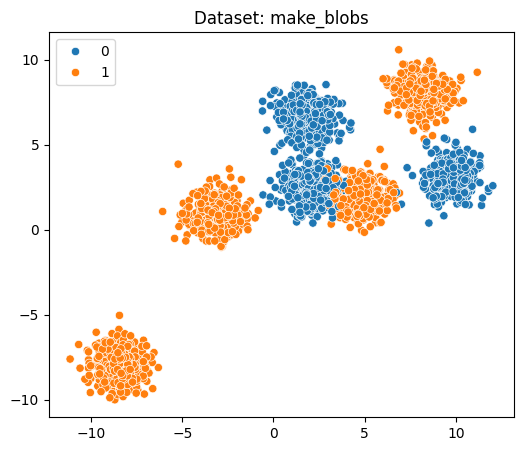

In [132]:
plot_data(X,y,"Dataset: make_blobs")

In [133]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=259202)

In [134]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((1876, 2), (1876,), (626, 2), (626,))

In [135]:
def plot_decision_boundary(X, y, model, title=""):
    h = 0.05
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )
    pts = np.c_[xx.ravel(), yy.ravel()]

    Z = model.predict(pts)

    Z = Z.reshape(xx.shape)

    # decition boundary
    plt.contourf(xx, yy, Z, alpha=0.3)

    # decision line
    plt.contour(xx, yy, Z, colors='k', linewidths=1)

    scatter = plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k')

    plt.legend(*scatter.legend_elements(), loc="upper right", title="Classes")
    plt.title(title)
    plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
    plt.show()

In [136]:
def to_one_hot(y, num_classes=2):
    return np.eye(num_classes)[y]

y_train_oh = to_one_hot(y_train)
y_test_oh = to_one_hot(y_test)

# Neural network

In [137]:
class NeuralNetwork:
    def __init__(self, layers, lr = 0.01, epochs = 100):
        self.layers = layers
        self.lr = lr
        self.epochs = epochs
        self.W = []
        self.b = []
        for i in range(len(layers) - 1):
            self.W.append(np.random.randn(layers[i], layers[i+1]))
            self.b.append(np.zeros((1, layers[i+1]))) 
            
    def relu(self, x):
        return np.maximum(0, x)
    
    def relu_derivative(self, x):
        return (x > 0 ).astype(float)
    
    def softmax(self, x):
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)
    
    def forward(self, X):
        self.cache = []
        a = X # input layer
        for i in range(len(self.W)):
            s = a @ self.W[i] + self.b[i]
            self.cache.append({'a': a, 's': s})
            if i < len(self.W) - 1:
                a = self.relu(s)
            else:
                a = self.softmax(s)
        return a
    
    def backward(self, y_true, output):
        grads_W = [None]*len(self.W)
        grads_b = [None]*len(self.W)
        grad = output - y_true
        
        for i in reversed(range(len(self.W))):
            a_prev = self.cache[i]['a']
            s = self.cache[i]['s']
            
            if i == len(self.W) - 1:
                ds = grad
            else:
                ds = grad * self.relu_derivative(s)
                
            grads_W[i] = a_prev.T @ ds / a_prev.shape[0]
            grads_b[i] = np.sum(ds, axis=0, keepdims=True) / a_prev.shape[0]
            
            if i > 0:
                grad = ds @ self.W[i].T
                
        return grads_W, grads_b
    
    def update(self, grads_W, grads_b):
        for i in range(len(self.W)):
            self.W[i] -= self.lr * grads_W[i]
            self.b[i] -= self.lr * grads_b[i]
    
    def fit(self, X, y):
        for epoch in range(self.epochs):
            out = self.forward(X)
            grads_W, grads_b = self.backward(y, out)
            self.update(grads_W, grads_b)
            if epoch % 50 == 0:
                loss = -np.mean(np.sum(y * np.log(out + 1e-8), axis=1))
                print(f"Epoch {epoch} - Loss: {loss}")
    
    def predict(self, X):
        out = self.forward(X)
        return np.argmax(out, axis=1) # index of the largest value in each row
    
    def score(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

In [181]:
nn = NeuralNetwork([X_train.shape[1], 10, 10, 2], lr = 0.05, epochs=500)
nn.fit(X_train, y_train_oh)
y_pred = nn.predict(X_test)
acc = np.mean(y_pred == y_test)
print(f"Accuracy: {acc}")

Epoch 0 - Loss: 10.511662138930935
Epoch 50 - Loss: 0.3968196024620893
Epoch 100 - Loss: 0.324369583065504
Epoch 150 - Loss: 0.29119763865262854
Epoch 200 - Loss: 0.26815902555921844
Epoch 250 - Loss: 0.24929052814680336
Epoch 300 - Loss: 0.22941962293313248
Epoch 350 - Loss: 0.21008997222552425
Epoch 400 - Loss: 0.18548005805652162
Epoch 450 - Loss: 0.14490609055687603
Accuracy: 0.9712460063897763


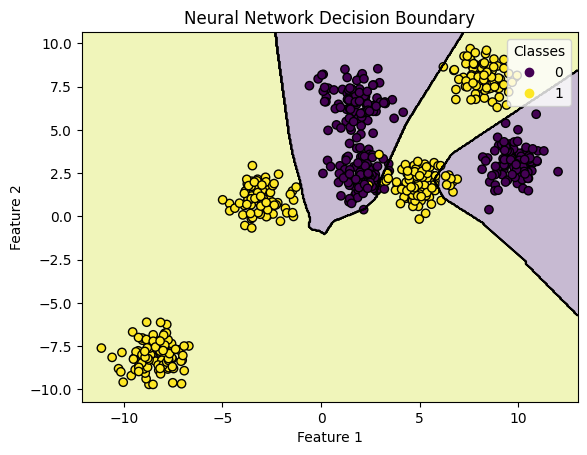

In [182]:
plot_decision_boundary(X_test, y_test, nn, title="Neural Network Decision Boundary")

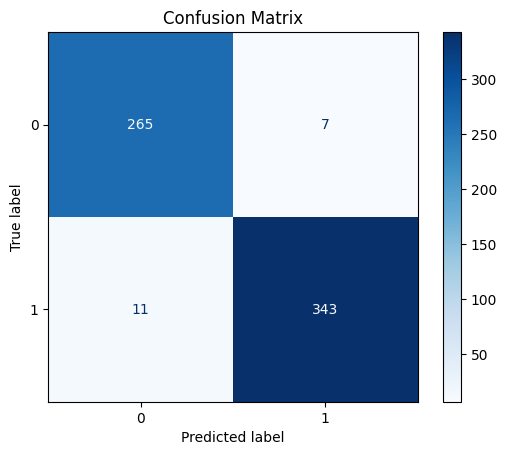

In [183]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [184]:
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn+fp) # swoisciwość
sensitivity = tp / (tp+fn) # czułość
print(f"Specificity: {specificity}\nSensitivity: {sensitivity}")

Specificity: 0.9742647058823529
Sensitivity: 0.9689265536723164
